# **ASSET FAILURE PREDICTION (CLASSIFICATION)**

## SECTION 1: Data Loading & Preprocessing

---



### 1.1 Real-World IoT Dataset Loading and Environment Setup

In [1]:
from pathlib import Path
from google.colab import drive

drive.mount("/content/drive")

RAW_DIR = Path("/content/drive/MyDrive/CSV/data_raw/classification")
CLEAN_DIR = Path("/content/drive/MyDrive/CSV/data_clean/classification")
CLEAN_DIR.mkdir(parents=True, exist_ok=True)
HORIZON_MINUTES = 30
print("Raw folder:", RAW_DIR)
print("Output folder:", CLEAN_DIR)


Mounted at /content/drive
Raw folder: /content/drive/MyDrive/CSV/data_raw/classification
Output folder: /content/drive/MyDrive/CSV/data_clean/classification


Required Imports

In [2]:
# Setup + Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import ParameterGrid

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve
)

### 1.2 Master File Map for HVAC, Pump, and Basic Assets

In [3]:
HVAC_FILES = {
  "AHU_01": RAW_DIR / "AHU 01 full.xlsx",
  "AHU_02": RAW_DIR / "AHU 02 full.xlsx",
  "AHU_03": RAW_DIR / "AHU 03 full.xlsx",
  "OAHU_19_02": RAW_DIR / "OAHU 19-02 full.xlsx",
  "OAHU_37_01": RAW_DIR / "OAHU 37-01 full.xlsx",
}

PUMP_FILES = {
  "PUMP_1": RAW_DIR / "CHW Pump 1 full.xlsx",
  "PUMP_2": RAW_DIR / "CHW Pump 2 full.xlsx",
}

BASIC_FILES = {
  "BP_BF_1D": RAW_DIR / "BP BF 1D full.xlsx",
  "BP_BF_1S": RAW_DIR / "BP BF 1S full.xlsx",
}

print("Missing HVAC:", [k for k,v in HVAC_FILES.items() if not v.exists()])
print("Missing PUMP:", [k for k,v in PUMP_FILES.items() if not v.exists()])
print("Missing BASIC:", [k for k,v in BASIC_FILES.items() if not v.exists()])

Missing HVAC: []
Missing PUMP: []
Missing BASIC: []


### 1.3 Helper Functions for Data Standardization & Feature Engineering

In [4]:
def standardize_df(df: pd.DataFrame) -> pd.DataFrame:
    """timestamp parsing, drop *_str columns, convert to numeric when possible."""
    df = df.copy()
    if "timestamp" not in df.columns:
        raise ValueError("No 'timestamp' column found.")

    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    df = df.dropna(subset=["timestamp"])

    str_cols = [c for c in df.columns if c.lower().endswith("_str")]
    df = df.drop(columns=str_cols, errors="ignore")

    for c in df.columns:
        if c == "timestamp":
            continue
        df[c] = pd.to_numeric(df[c], errors="coerce")

    return df


def cols_containing(df: pd.DataFrame, includes):
    includes = [s.lower() for s in includes]
    out = []
    for c in df.columns:
        name = c.lower()
        if any(s in name for s in includes):
            out.append(c)
    return out


def estimate_step_minutes(timestamps: pd.Series) -> float:
    dt = timestamps.sort_values().diff().dropna()
    if dt.empty:
        return np.nan
    mode = dt.value_counts().idxmax()
    return mode.total_seconds() / 60.0


def steps_for_horizon(df: pd.DataFrame, horizon_minutes: int) -> int:
    step_min = estimate_step_minutes(df["timestamp"])
    if not np.isfinite(step_min) or step_min <= 0:
        return 1
    steps = int(round(horizon_minutes / step_min))
    return max(1, steps)


def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    ts = df["timestamp"]
    df["hour"] = ts.dt.hour
    df["dayofweek"] = ts.dt.dayofweek
    df["month"] = ts.dt.month
    df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)
    return df


def build_future_failure(df: pd.DataFrame, steps_ahead: int) -> pd.DataFrame:
    df = df.copy().sort_values("timestamp").reset_index(drop=True)
    s = df["failure_event"].astype(int)

    future = np.zeros(len(s), dtype=int)
    for i in range(1, steps_ahead + 1):
        future = np.maximum(future, s.shift(-i).fillna(0).astype(int).to_numpy())

    df["future_failure"] = future

    # drop last rows that don't have full look-ahead window
    if steps_ahead > 0:
        df = df.iloc[:-steps_ahead].copy()

    return df

### 1.4 Standardizing Column Names Across HVAC, Pump, and Basic Assets

In [5]:
def strip_asset_prefix(col: str) -> str:
    """
    Removes NETIX-style prefixes like:
      143138_AHU 01_10507_On Coil Temperature  -> on_coil_temperature
      143143_OAHU 37-01_20031_PM2_5            -> pm2_5
    """
    if col == "timestamp":
        return col

    # Normalize separators
    c = col.replace("  ", " ").strip()

    parts = c.split("_")

    # Find last "numeric-like" token and take everything after it, numeric-like examples: "10507", "20031"
    idx = None
    for i, p in enumerate(parts):
        if p.strip().isdigit():
            idx = i

    if idx is not None and idx + 1 < len(parts):
        semantic = "_".join(parts[idx+1:])
    else:
        # fallback: drop first 2 parts if they look like asset prefix
        semantic = "_".join(parts[-3:]) if len(parts) > 3 else c

    semantic = semantic.lower().strip()

    # Light normalization
    semantic = semantic.replace(" ", "_")
    semantic = semantic.replace("__", "_")
    semantic = semantic.replace("-", "_")
    return semantic


def standardize_columns_across_assets(df: pd.DataFrame) -> pd.DataFrame:
    """Apply prefix stripping to all columns (except timestamp)."""
    rename_map = {c: strip_asset_prefix(c) for c in df.columns}
    return df.rename(columns=rename_map)


### 1.5 Handling Missing Values & Time-Based Train/Validation/Test Splits per Asset

In [6]:
def drop_high_missing_cols(df: pd.DataFrame, threshold=0.70) -> pd.DataFrame:
    """Drop columns with missing rate > threshold (excluding required columns)."""

    df = df.copy()
    required = {"timestamp", "asset_id", "asset_type", "future_failure", "failure_event"}
    missing_rate = df.isna().mean()
    drop_cols = [c for c in df.columns if (missing_rate.get(c, 0) > threshold) and (c not in required)]
    return df.drop(columns=drop_cols, errors="ignore")


def ffill_by_asset(df: pd.DataFrame) -> pd.DataFrame:
    """Forward-fill within each asset_id by timestamp."""
    df = df.sort_values(["asset_id", "timestamp"]).copy()
    df = df.groupby("asset_id", group_keys=False).apply(lambda g: g.ffill())
    return df.reset_index(drop=True)


def compute_train_medians(train_df: pd.DataFrame) -> pd.Series:
    """Compute medians from TRAIN ONLY for numeric columns (excluding targets)."""
    numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
    for c in ["future_failure", "failure_event"]:
        if c in numeric_cols:
            numeric_cols.remove(c)
    return train_df[numeric_cols].median(numeric_only=True)


def apply_train_medians(df: pd.DataFrame, medians: pd.Series) -> pd.DataFrame:
    """Fill remaining NaNs in numeric columns using TRAIN medians (no leakage)."""
    df = df.copy()
    numeric_cols = [c for c in medians.index if c in df.columns]
    df[numeric_cols] = df[numeric_cols].fillna(medians)
    return df


def split_time_per_asset(df: pd.DataFrame, train=0.70, val=0.15):
    """Time split within each asset_id, then concatenate splits."""
    trains, vals, tests = [], [], []
    for aid, g in df.groupby("asset_id"):
        g = g.sort_values("timestamp").reset_index(drop=True)
        n = len(g)
        t_end = int(n * train)
        v_end = int(n * (train + val))
        trains.append(g.iloc[:t_end])
        vals.append(g.iloc[t_end:v_end])
        tests.append(g.iloc[v_end:])
    return (pd.concat(trains).reset_index(drop=True),
            pd.concat(vals).reset_index(drop=True),
            pd.concat(tests).reset_index(drop=True))


## SECTION 2: Master Dataset Construction & Export

---



### 2.1 Build Group Master DataFrames for HVAC, Pump, and Basic Assets

In [7]:
def build_group_master(file_map: dict, asset_type: str) -> pd.DataFrame:
    frames = []

    for asset_id, path in file_map.items():
        try:
            df = pd.read_excel(path)
            df = standardize_df(df)

            # Standardize column names across assets (removes prefixes)
            df = standardize_columns_across_assets(df)

            # --- Start fix for duplicate column names ---
            # Ensure column names are unique by adding suffixes if duplicates were created
            cols = pd.Series(df.columns)
            for dup in cols[cols.duplicated()].unique():
                indices = cols[cols == dup].index.tolist()
                for i, idx in enumerate(indices):
                    # For duplicate names, append a unique suffix
                    if i > 0:
                        df.columns.values[idx] = f"{dup}_{i}"
            # --- End fix for duplicate column names ---

            # Add identifiers
            df["asset_id"] = asset_id
            df["asset_type"] = asset_type

            # --- Build failure_event + leakage cols (NO ambiguous checks) ---
            leakage_cols = []

            if asset_type == "HVAC":
                trip_cols = list(cols_containing(df, ["trip"]))
                leakage_cols = trip_cols

                if len(trip_cols) == 0:
                    df["failure_event"] = 0
                else:
                    raw_flag = (df[trip_cols].fillna(0) > 0).any(axis=1).astype(int)
                    # Use rising edge to mark the actual event start (prevents long runs of 1s)
                    df["failure_event"] = ((raw_flag == 1) & (raw_flag.shift(1).fillna(0) == 0)).astype(int)

            elif asset_type == "PUMP":
                trip_cols  = list(cols_containing(df, ["trip"]))
                alarm_cols = list(cols_containing(df, ["alarm", "issue"]))
                leakage_cols = sorted(set(trip_cols + alarm_cols))

                if len(leakage_cols) == 0:
                    df["failure_event"] = 0
                else:
                    raw_flag = (df[leakage_cols].fillna(0) > 0).any(axis=1).astype(int)
                    df["failure_event"] = ((raw_flag == 1) & (raw_flag.shift(1).fillna(0) == 0)).astype(int)

            else:  # BASIC
                trip_cols = list(cols_containing(df, ["trip"]))
                leakage_cols = trip_cols

                if len(trip_cols) == 0:
                    df["failure_event"] = 0
                else:
                    raw_flag = (df[trip_cols].fillna(0) > 0).any(axis=1).astype(int)
                    # Use rising edge to mark the actual event start (prevents long runs of 1s)
                    df["failure_event"] = ((raw_flag == 1) & (raw_flag.shift(1).fillna(0) == 0)).astype(int)

            # --- Create future_failure ---
            steps = steps_for_horizon(df, HORIZON_MINUTES)
            df = build_future_failure(df, steps_ahead=steps)

            # --- Add time features ---
            df = add_time_features(df)

            # --- Drop leakage columns (trip/alarm/issue) ---
            if isinstance(leakage_cols, (list, tuple)) and len(leakage_cols) > 0:
                df = df.drop(columns=leakage_cols, errors="ignore")

            # Drop columns that are entirely NaN for this asset
            all_nan_cols = [c for c in df.columns if df[c].isna().all()]
            if len(all_nan_cols) > 0:
                df = df.drop(columns=all_nan_cols, errors="ignore")

            frames.append(df)

            print(f"{asset_type} | {asset_id} | rows={len(df)} | horizon_steps={steps}")

        except Exception as e:
            print(f"\n ERROR while processing: {asset_type} | {asset_id} | file={path.name}")
            raise  # re-raise so you still get the full traceback

    return pd.concat(frames, ignore_index=True)


# Build masters
hvac_master = build_group_master(HVAC_FILES, "HVAC")
pump_master = build_group_master(PUMP_FILES, "PUMP")
basic_master = build_group_master(BASIC_FILES, "BASIC")

print("\n--- Masters Built ---")
print("HVAC:", hvac_master.shape)
print("PUMP:", pump_master.shape)
print("BASIC:", basic_master.shape)

HVAC | AHU_01 | rows=44577 | horizon_steps=6
HVAC | AHU_02 | rows=49237 | horizon_steps=6
HVAC | AHU_03 | rows=49834 | horizon_steps=6
HVAC | OAHU_19_02 | rows=50208 | horizon_steps=6
HVAC | OAHU_37_01 | rows=49309 | horizon_steps=6
PUMP | PUMP_1 | rows=45628 | horizon_steps=6
PUMP | PUMP_2 | rows=45555 | horizon_steps=6
BASIC | BP_BF_1D | rows=10690 | horizon_steps=6
BASIC | BP_BF_1S | rows=13348 | horizon_steps=6

--- Masters Built ---
HVAC: (243165, 61)
PUMP: (91183, 40)
BASIC: (24038, 11)


### 2.2 Missing Data Imputation and Finalization of Master DataFrames

In [8]:
def finalize_master(df: pd.DataFrame, name: str) -> pd.DataFrame:
    """Final light tidy before splitting.

    We intentionally DO NOT:
    - back-fill (bfill)  -> leakage (uses future)
    - median-fill on full dataset -> leakage (peeks at val/test)

    Those are handled safely AFTER splitting, using TRAIN-only statistics.
    """
    df = df.copy()
    df = df.sort_values(["asset_id", "timestamp"]).reset_index(drop=True)
    print(f"\n{name} pre-split shape:", df.shape)
    return df

hvac_master = finalize_master(hvac_master, "HVAC")
pump_master = finalize_master(pump_master, "PUMP")
basic_master = finalize_master(basic_master, "BASIC")



HVAC pre-split shape: (243165, 61)

PUMP pre-split shape: (91183, 40)

BASIC pre-split shape: (24038, 11)


### 2.3 Time-Based Train/Validation/Test Split and Save Masters

In [9]:
def save_group(prefix: str, df: pd.DataFrame):
    # 1) Split first (time-based per asset)
    train_df, val_df, test_df = split_time_per_asset(df, train=0.70, val=0.15)

    # 2) Drop high-missing columns using TRAIN ONLY, apply the same columns to val/test
    train_df_dropped = drop_high_missing_cols(train_df, threshold=0.70)
    keep_cols = train_df_dropped.columns.tolist()

    train_df = train_df[keep_cols].copy()
    val_df   = val_df[keep_cols].copy()
    test_df  = test_df[keep_cols].copy()

    # 3) Forward-fill within each split (NO back-fill)
    train_df = ffill_by_asset(train_df)
    val_df   = ffill_by_asset(val_df)
    test_df  = ffill_by_asset(test_df)

    # 4) Median-fill remaining numeric NaNs using TRAIN medians ONLY
    medians = compute_train_medians(train_df)
    train_df = apply_train_medians(train_df, medians)
    val_df   = apply_train_medians(val_df, medians)
    test_df  = apply_train_medians(test_df, medians)

    # 5) Save outputs
    df_master = pd.concat([train_df, val_df, test_df]).sort_values(["asset_id", "timestamp"]).reset_index(drop=True)

    df_master.to_parquet(CLEAN_DIR / f"{prefix}_master.parquet", index=False)
    train_df.to_parquet(CLEAN_DIR / f"{prefix}_train.parquet", index=False)
    val_df.to_parquet(CLEAN_DIR / f"{prefix}_val.parquet", index=False)
    test_df.to_parquet(CLEAN_DIR / f"{prefix}_test.parquet", index=False)

    df_master.to_csv(CLEAN_DIR / f"{prefix}_master.csv", index=False)

    print(f"\nSaved {prefix}:")
    print(" master:", df_master.shape)
    print(" train :", train_df.shape)
    print(" val   :", val_df.shape)
    print(" test  :", test_df.shape)
    print(" kept columns:", len(keep_cols))

save_group("classification_hvac", hvac_master)
save_group("classification_pump", pump_master)
# basic is scrapped later, but keep export for traceability if you want:
save_group("classification_basic", basic_master)

print("\nAll outputs saved to:", CLEAN_DIR)


/tmp/ipykernel_291/4060825717.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("asset_id", group_keys=False).apply(lambda g: g.ffill())
/tmp/ipykernel_291/4060825717.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("asset_id", group_keys=False).apply(lambda g: g.ffill())
/tmp/ipykernel_291/4060825717.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the gr


Saved classification_hvac:
 master: (243165, 54)
 train : (170212, 54)
 val   : (36475, 54)
 test  : (36478, 54)
 kept columns: 54


/tmp/ipykernel_291/4060825717.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("asset_id", group_keys=False).apply(lambda g: g.ffill())
/tmp/ipykernel_291/4060825717.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("asset_id", group_keys=False).apply(lambda g: g.ffill())
/tmp/ipykernel_291/4060825717.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the gr


Saved classification_pump:
 master: (91183, 40)
 train : (63827, 40)
 val   : (13677, 40)
 test  : (13679, 40)
 kept columns: 40


/tmp/ipykernel_291/4060825717.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("asset_id", group_keys=False).apply(lambda g: g.ffill())
/tmp/ipykernel_291/4060825717.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("asset_id", group_keys=False).apply(lambda g: g.ffill())
/tmp/ipykernel_291/4060825717.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the gr


Saved classification_basic:
 master: (24038, 11)
 train : (16825, 11)
 val   : (3606, 11)
 test  : (3607, 11)
 kept columns: 11

All outputs saved to: /content/drive/MyDrive/CSV/data_clean/classification


## SECTION 3: HVAC Failure Prediction

---




### 3.1 Common helpers (metrics + plots)

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

SEED = 42

def eval_probs(y_true, y_prob, thr=0.5):
    y_pred = (y_prob >= thr).astype(int)
    return {
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan,
        "cm": confusion_matrix(y_true, y_pred),
    }

def best_threshold_f1(y_true, y_prob):
    thresholds = np.linspace(0.05, 0.95, 19)
    best_thr, best_f1 = 0.5, -1
    for thr in thresholds:
        m = eval_probs(y_true, y_prob, thr)
        if m["f1"] > best_f1:
            best_f1 = m["f1"]
            best_thr = thr
    return float(best_thr), float(best_f1)

def plot_cm(cm, title):
    plt.figure(figsize=(5,4))
    plt.imshow(cm)
    plt.title(title)
    plt.xticks([0,1], ["No Failure", "Failure"])
    plt.yticks([0,1], ["No Failure", "Failure"])
    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

def plot_roc(y_true, y_prob, title):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan
    plt.figure(figsize=(5,4))
    plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
    plt.plot([0,1],[0,1],"k--")
    plt.title(title)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

def make_Xy_simple(df, target="future_failure"):
    # drop IDs/time/current-failure flag
    drop_cols = [target, "asset_id", "asset_type", "timestamp", "failure_event"]
    y = df[target].astype(int).values
    X = df.drop(columns=drop_cols, errors="ignore").copy()
    # force numeric
    X = X.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
    return X, y

def fill_with_train_medians(X_train, X_val, X_test):
    med = X_train.median(numeric_only=True)
    return X_train.fillna(med), X_val.fillna(med), X_test.fillna(med)

### 3.2 HVAC Failure Classification — Logistic Regression

#### 3.2.1 Data Loading

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [16]:
train = pd.read_parquet("/content/drive/MyDrive/CSV/data_clean/classification/classification_hvac_train.parquet")
val   = pd.read_parquet("/content/drive/MyDrive/CSV/data_clean/classification/classification_hvac_val.parquet")
test  = pd.read_parquet("/content/drive/MyDrive/CSV/data_clean/classification/classification_hvac_test.parquet")


#### 3.2.2 Feature & Target Preparation

In [17]:
TARGET = "future_failure"
drop_cols = ["asset_id", "asset_type", "timestamp"]  # drop if present

X_train = train.drop(columns=[TARGET] + drop_cols, errors="ignore")
y_train = train[TARGET]

X_val = val.drop(columns=[TARGET] + drop_cols, errors="ignore")
y_val = val[TARGET]

X_test = test.drop(columns=[TARGET] + drop_cols, errors="ignore")
y_test = test[TARGET]


#### 3.2.3 Feature Scaling & Model Training

In [18]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

In [19]:
logreg = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight="balanced"  # important if failures are rare
)

logreg.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

#### 3.2.4 Validation Metrics

In [20]:
val_preds = logreg.predict(X_val_scaled)
val_probs = logreg.predict_proba(X_val_scaled)[:, 1]

print("Validation Metrics")
print("Accuracy:", accuracy_score(y_val, val_preds))
print("Precision:", precision_score(y_val, val_preds))
print("Recall:", recall_score(y_val, val_preds))
print("F1:", f1_score(y_val, val_preds))
print("ROC-AUC:", roc_auc_score(y_val, val_probs))

Validation Metrics
Accuracy: 0.7519945167923235
Precision: 0.6454272863568216
Recall: 0.6660993346742998
F1: 0.6556003959491358
ROC-AUC: 0.8613677235703442


#### 3.2.5 Confusion Matrix

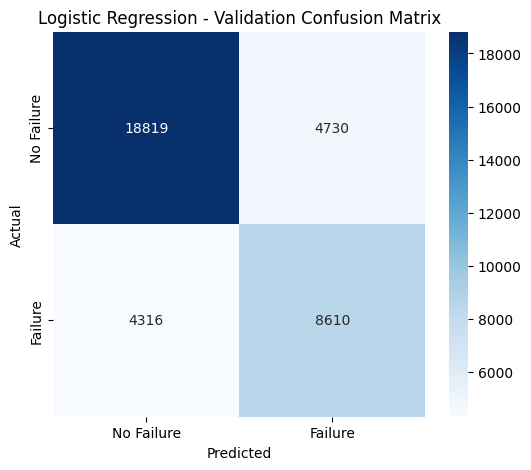

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, val_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["No Failure", "Failure"],
            yticklabels=["No Failure", "Failure"])
plt.title("Logistic Regression - Validation Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### 3.2.6 ROC Curve

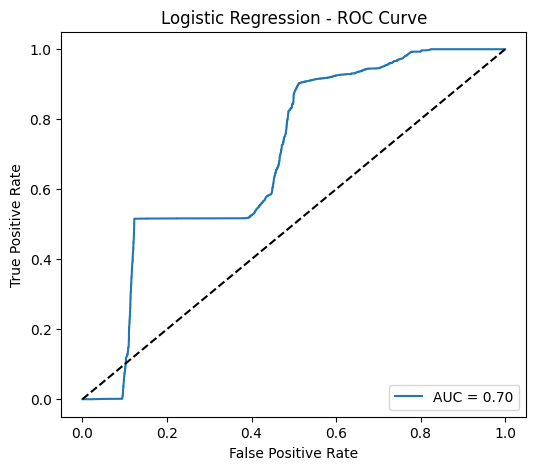

In [22]:
from sklearn.metrics import roc_curve, auc

test_probs = logreg.predict_proba(X_test_scaled)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, test_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], "k--")

plt.title("Logistic Regression - ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

### 3.3 HVAC Failure Classification — Decision Tree

#### 3.3.1 Data Loading

In [23]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [25]:
train = pd.read_parquet("/content/drive/MyDrive/CSV/data_clean/classification/classification_hvac_train.parquet")
val   = pd.read_parquet("/content/drive/MyDrive/CSV/data_clean/classification/classification_hvac_val.parquet")
test  = pd.read_parquet("/content/drive/MyDrive/CSV/data_clean/classification/classification_hvac_test.parquet")

#### 3.3.2 Feature & Target Preparation

In [26]:
TARGET = "future_failure"
drop_cols = ["asset_id", "asset_type", "timestamp"]

X_train = train.drop(columns=[TARGET] + drop_cols, errors="ignore")
y_train = train[TARGET]

X_val = val.drop(columns=[TARGET] + drop_cols, errors="ignore")
y_val = val[TARGET]

X_test = test.drop(columns=[TARGET] + drop_cols, errors="ignore")
y_test = test[TARGET]

#### 3.3.3 Model Training

In [94]:
dt = DecisionTreeClassifier(
    random_state=42
)
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

#### 3.3.4 Validation Metrics

In [95]:
val_preds = dt.predict(X_val)
val_probs = dt.predict_proba(X_val)[:, 1]  # probability for ROC-AUC

print("Validation Metrics")
print("Accuracy:", accuracy_score(y_val, val_preds))
print("Precision:", precision_score(y_val, val_preds))
print("Recall:", recall_score(y_val, val_preds))
print("F1:", f1_score(y_val, val_preds))
print("ROC-AUC:", roc_auc_score(y_val, val_probs))

Validation Metrics
Accuracy: 0.41485705929662936
Precision: 0.48005849508109544
Recall: 0.4687783980267428
F1: 0.47435139573070606
ROC-AUC: 0.40703070873434366


#### 3.3.5 Decision Tree Visualization

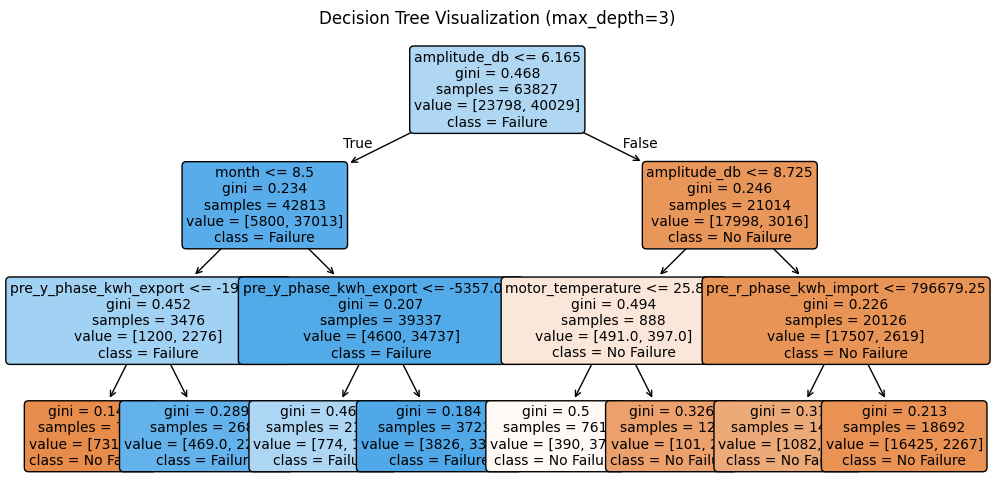

In [96]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Train a shallow copy of the tree for visualization
dt_viz = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_viz.fit(X_train, y_train)

plt.figure(figsize=(12,6))
plot_tree(dt_viz,
          feature_names=X_train.columns,
          class_names=["No Failure", "Failure"],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Decision Tree Visualization (max_depth=3)")
plt.show()

#### 3.3.6 Confusion Matrix

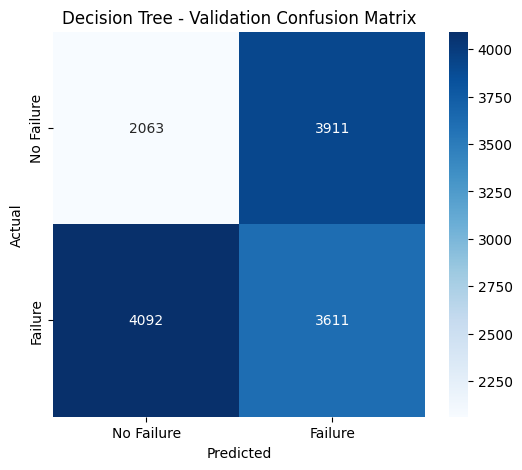

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, val_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["No Failure", "Failure"],
            yticklabels=["No Failure", "Failure"])
plt.title("Decision Tree - Validation Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### 3.3.7 ROC Curve

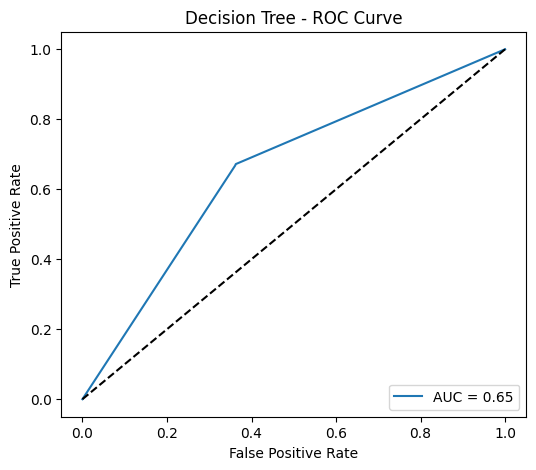

In [100]:
from sklearn.metrics import roc_curve, auc

test_probs = dt.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, test_probs)
roc_auc = auc(fpr, tpr)

# Flip if AUC < 0.5 (model predicting inverted)
if roc_auc < 0.5:
    test_probs = 1 - test_probs
    fpr, tpr, thresholds = roc_curve(y_test, test_probs)
    roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], "k--")
plt.title("Decision Tree - ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

### 3.4 HVAC Failure Classification — Random Forest

#### 3.4.1 Data Loading

In [30]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [32]:
train = pd.read_parquet("/content/drive/MyDrive/CSV/data_clean/classification/classification_hvac_train.parquet")
val   = pd.read_parquet("/content/drive/MyDrive/CSV/data_clean/classification/classification_hvac_val.parquet")
test  = pd.read_parquet("/content/drive/MyDrive/CSV/data_clean/classification/classification_hvac_test.parquet")

#### 3.4.2 Feature & Target Preparation

In [33]:
TARGET = "future_failure"

X_train = train.drop(columns=[TARGET])
y_train = train[TARGET]

X_val = val.drop(columns=[TARGET])
y_val = val[TARGET]

X_test = test.drop(columns=[TARGET])
y_test = test[TARGET]


#### 3.4.3 Dropping Unnecessary Columns

In [34]:
cols_to_drop = ["asset_id", "asset_type"]

X_train = X_train.drop(columns=cols_to_drop)
X_val   = X_val.drop(columns=cols_to_drop)
X_test  = X_test.drop(columns=cols_to_drop)

In [35]:
# Drop timestamp column if present
for df in [X_train, X_val, X_test]:
    if "timestamp" in df.columns:
        df.drop(columns=["timestamp"], inplace=True)

#### 3.4.4 Model Training

In [36]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

#### 3.4.5 Validation Metrics

In [37]:
val_preds = rf.predict(X_val)
val_probs = rf.predict_proba(X_val)[:, 1]

print("Validation Metrics")
print("Accuracy:", accuracy_score(y_val, val_preds))
print("Precision:", precision_score(y_val, val_preds))
print("Recall:", recall_score(y_val, val_preds))
print("F1:", f1_score(y_val, val_preds))
print("ROC-AUC:", roc_auc_score(y_val, val_probs))

Validation Metrics
Accuracy: 0.86368745716244
Precision: 0.8056879323597232
Recall: 0.8109237196348446
F1: 0.8082973473164713
ROC-AUC: 0.9166390391302043


#### 3.4.6 Confusion Matrix

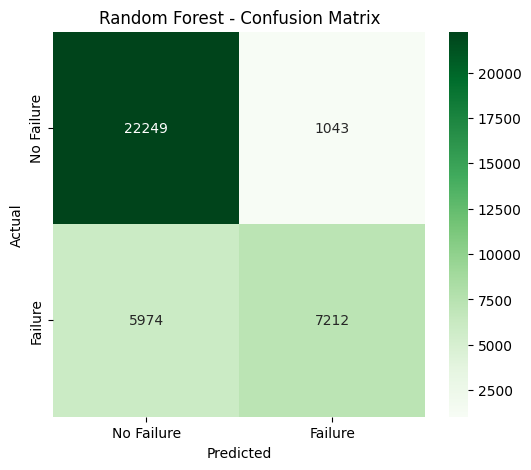

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Predictions
test_preds_rf = rf.predict(X_test)

# Confusion Matrix
cm_rf = confusion_matrix(y_test, test_preds_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens",
            xticklabels=["No Failure", "Failure"],
            yticklabels=["No Failure", "Failure"])
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### 3.4.7 Predictions vs Actuals Scatterplot

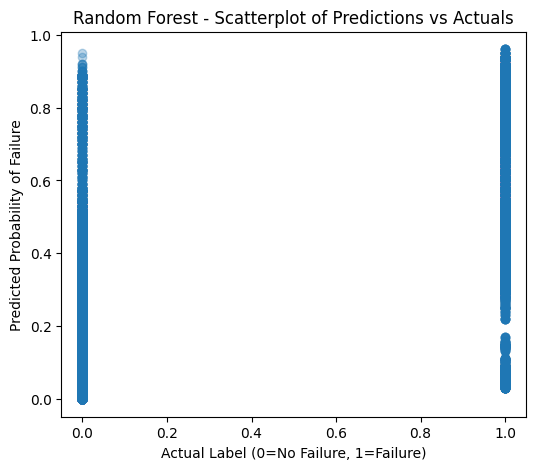

In [39]:
# Predicted probabilities of class 1 (failure)
test_probs_rf = rf.predict_proba(X_test)[:, 1]

plt.figure(figsize=(6,5))
plt.scatter(y_test, test_probs_rf, alpha=0.3)
plt.xlabel("Actual Label (0=No Failure, 1=Failure)")
plt.ylabel("Predicted Probability of Failure")
plt.title("Random Forest - Scatterplot of Predictions vs Actuals")
plt.show()

#### 3.4.8 ROC Curve

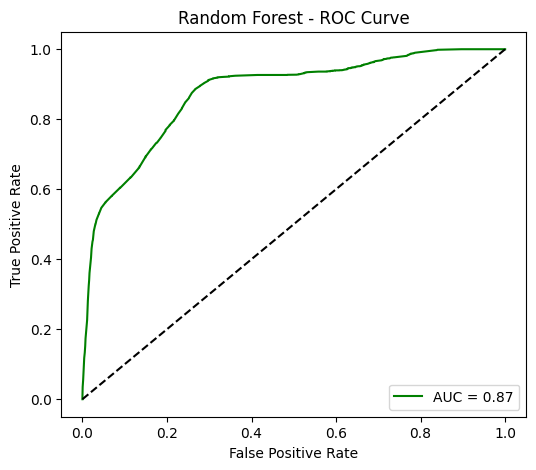

In [40]:
from sklearn.metrics import roc_curve, auc

fpr_rf, tpr_rf, _ = roc_curve(y_test, test_probs_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(6,5))
plt.plot(fpr_rf, tpr_rf, label=f"AUC = {roc_auc_rf:.2f}", color="green")
plt.plot([0,1], [0,1], "k--")
plt.title("Random Forest - ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

### 3.6 HVAC - Compare models (Validation) + select best

In [89]:
hvac_val_table = pd.DataFrame([
    {"model":"LogReg", "val_f1": best_lr_f1_hvac, "thr": best_lr_thr_hvac},
    {"model":"DecTree", "val_f1": best_dt_f1_hvac, "thr": best_dt_thr_hvac},
    {"model":"RandForest", "val_f1": best_rf_f1_hvac, "thr": best_rf_thr_hvac},
]).sort_values("val_f1", ascending=False)

display(hvac_val_table)

best_model_name_hvac = hvac_val_table.iloc[0]["model"]
best_thr_final_hvac = float(hvac_val_table.iloc[0]["thr"])

if best_model_name_hvac == "LogReg":
    best_model_hvac = best_lr_hvac
elif best_model_name_hvac == "DecTree":
    best_model_hvac = best_dt_hvac
else:
    best_model_hvac = best_rf_hvac

print("Selected HVAC model:", best_model_name_hvac, "thr:", round(best_thr_final_hvac,2))


,model,val_f1,thr
2,RandForest,0.826937,0.45
0,LogReg,0.725385,0.65
1,DecTree,0.680811,0.65


Selected HVAC model: RandForest thr: 0.45


### 3.7 HVAC - Final train (Train+Val) + Test evaluation

HVAC TEST — RandForest
Precision: 0.8323 Recall: 0.8029 F1: 0.8173 AUC: 0.7325


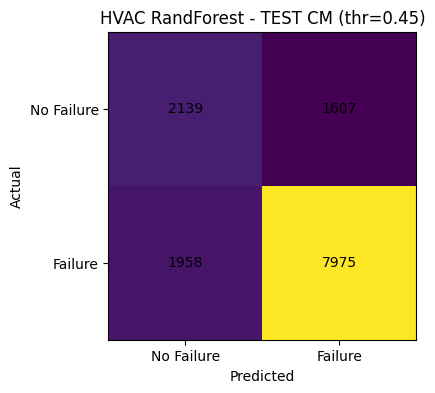

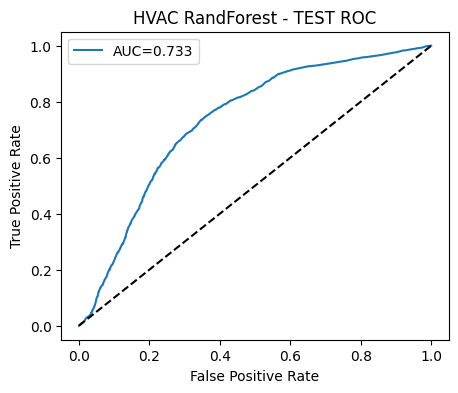

In [90]:
X_trainval_hvac = pd.concat([X_train, X_val], axis=0)
y_trainval_hvac = np.concatenate([y_train, y_val])

if best_model_name_hvac == "LogReg":
    scaler_hvac_final = StandardScaler()
    Xtrv = scaler_hvac_final.fit_transform(X_trainval_hvac)
    Xte  = scaler_hvac_final.transform(X_test)
    best_model_hvac.fit(Xtrv, y_trainval_hvac)
    test_prob_hvac = best_model_hvac.predict_proba(Xte)[:,1]
else:
    best_model_hvac.fit(X_trainval_hvac, y_trainval_hvac)
    test_prob_hvac = best_model_hvac.predict_proba(X_test)[:,1]

m_test = eval_probs(y_test, test_prob_hvac, best_thr_final_hvac)
print("HVAC TEST —", best_model_name_hvac)
print("Precision:", round(m_test["precision"],4), "Recall:", round(m_test["recall"],4), "F1:", round(m_test["f1"],4), "AUC:", round(m_test["roc_auc"],4))
plot_cm(m_test["cm"], f"HVAC {best_model_name_hvac} - TEST CM (thr={best_thr_final_hvac:.2f})")
plot_roc(y_test, test_prob_hvac, f"HVAC {best_model_name_hvac} - TEST ROC")

In [50]:
print("Test positive rate:", y_test.mean())

Test positive rate: 0.3614781512144306


In [51]:
print(y_train.mean())
print(y_val.mean())
print(y_test.mean())

0.41992926468169106
0.35437971213159697
0.3614781512144306


### 3.8 HVAC - Feature importance / coefficients

,0
valve_command,0.111365
return_air_temperature,0.098597
on_coil_temperature,0.073650
co2,0.071650
return_air_humidity,0.068313
off_coil_temperature,0.060374
hour,0.060022
supply_air_temperature,0.048867
return_air_temperature_setpoint,0.036527
supply_fan_run_status,0.035748


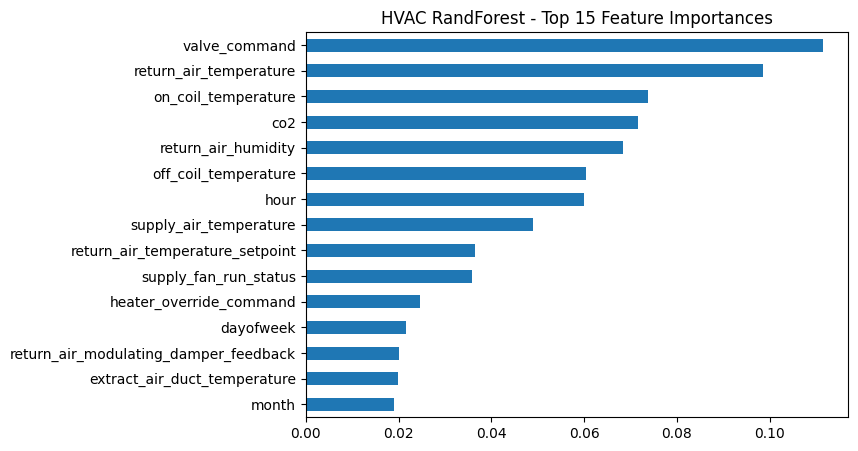

In [52]:
if best_model_name_hvac in ["DecTree", "RandForest"]:
    importances = pd.Series(best_model_hvac.feature_importances_, index=X_train.columns).sort_values(ascending=False)
    display(importances.head(15))
    plt.figure(figsize=(7,5))
    importances.head(15).iloc[::-1].plot(kind="barh")
    plt.title(f"HVAC {best_model_name_hvac} - Top 15 Feature Importances")
    plt.show()
elif best_model_name_hvac == "LogReg":
    coefs = pd.Series(best_model_hvac.coef_[0], index=X_train.columns).sort_values(key=abs, ascending=False)
    display(coefs.head(15))
    plt.figure(figsize=(7,5))
    coefs.head(15).iloc[::-1].plot(kind="barh")
    plt.title("HVAC Logistic Regression - Top 15 Coefficients")
    plt.show()

### 3.9 HVAC - Error analysis (False Negatives / False Positives)

In [53]:
hvac_pred_test = (test_prob_hvac >= best_thr_final_hvac).astype(int)
err_hvac = X_test.copy()
err_hvac["actual"] = y_test
err_hvac["pred"] = hvac_pred_test
err_hvac["prob"] = test_prob_hvac

fn_hvac = err_hvac[(err_hvac["actual"]==1) & (err_hvac["pred"]==0)]
fp_hvac = err_hvac[(err_hvac["actual"]==0) & (err_hvac["pred"]==1)]

print("HVAC False Negatives:", len(fn_hvac))
print("HVAC False Positives:", len(fp_hvac))

# top uncertain false negatives (closest to threshold)
display(fn_hvac.sort_values("prob", ascending=False).head(10))

HVAC False Negatives: 1299
HVAC False Positives: 2906


,co2,on_coil_temperature,off_coil_temperature,valve_command,supply_fan_run_status,supply_fan_command,supply_fan_air_flow_status,supply_air_temperature,return_air_temperature,return_air_humidity,...,off_coil_temperature_setpoint,supply_air_humidity_setpoint,return_air_temperature_1,pm10,voc_equal_co2,ch2o,humidity,actual,pred,prob
452,448.000000,21.40,13.07,0.0,2.0,1.0,1.0,15.37,20.07,61.68,...,21.0,30.0,18.496250,25.561952,400.000000,0.0,66.513435,1,0,0.443333
455,448.000000,21.40,13.10,0.0,2.0,1.0,1.0,15.40,20.15,61.43,...,21.0,30.0,18.496250,25.561952,400.000000,0.0,66.513435,1,0,0.443333
1400,494.000000,21.65,12.77,0.0,2.0,1.0,1.0,15.10,20.34,51.43,...,21.0,30.0,18.496250,25.561952,400.000000,0.0,66.513435,1,0,0.440000
27961,597.763636,-34.24,10.81,0.0,2.0,2.0,1.0,13.02,16.81,47.27,...,20.0,35.0,18.852364,17.290909,1012.727273,0.0,68.804364,1,0,0.440000
27962,596.311111,-34.24,10.81,0.0,2.0,2.0,1.0,13.02,16.81,47.27,...,20.0,35.0,18.840889,17.600000,1004.822222,0.0,68.788000,1,0,0.440000
27963,593.540000,-34.24,10.81,0.0,2.0,2.0,1.0,13.02,16.81,47.27,...,20.0,35.0,18.841800,17.920000,996.220000,0.0,68.798000,1,0,0.440000
1272,450.000000,21.60,12.87,0.0,2.0,1.0,1.0,15.20,20.01,60.95,...,21.0,30.0,18.496250,25.561952,400.000000,0.0,66.513435,1,0,0.440000
28471,704.361702,-34.24,10.81,0.0,2.0,2.0,1.0,13.02,16.81,47.27,...,20.0,35.0,18.794894,21.510638,533.638298,0.0,68.076170,1,0,0.440000
28133,714.750000,-34.24,10.81,0.0,2.0,2.0,1.0,13.02,16.81,47.27,...,20.0,35.0,18.548393,25.875000,868.000000,0.0,68.526786,1,0,0.440000
28472,696.622642,-34.24,10.81,0.0,2.0,2.0,1.0,13.02,16.81,47.27,...,20.0,35.0,18.799434,21.962264,539.000000,0.0,68.189434,1,0,0.440000


## SECTION 4: PUMP Failure Prediction

---

### 4.1 Pump Failure Classification — Logistic Regression

#### 4.1.1 Data Loading

In [54]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [55]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [56]:
train = pd.read_parquet("/content/drive/MyDrive/CSV/data_clean/classification/classification_pump_train.parquet")
val   = pd.read_parquet("/content/drive/MyDrive/CSV/data_clean/classification/classification_pump_val.parquet")
test  = pd.read_parquet("/content/drive/MyDrive/CSV/data_clean/classification/classification_pump_test.parquet")

print(train.shape, val.shape, test.shape, '\n')
print("future_failure train:\n", train["future_failure"].value_counts())
print()
print("future_failure val:\n", val["future_failure"].value_counts())

(63827, 40) (13677, 40) (13679, 40) 

future_failure train:
 future_failure
1    40029
0    23798
Name: count, dtype: int64

future_failure val:
 future_failure
1    7703
0    5974
Name: count, dtype: int64


#### 4.1.2 Feature & Target Preparation

In [57]:
TARGET = "future_failure"
drop_cols = ["asset_id", "asset_type", "timestamp", "failure_event"]

X_train = train.drop(columns=[TARGET] + drop_cols, errors="ignore")
y_train = train[TARGET]

X_val = val.drop(columns=[TARGET] + drop_cols, errors="ignore")
y_val = val[TARGET]

X_test = test.drop(columns=[TARGET] + drop_cols, errors="ignore")
y_test = test[TARGET]

print("Columns used:", X_train.shape[1])

Columns used: 35


#### 4.1.4 Model Training

In [58]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

best_lr_pump = None
best_lr_params_pump = None
best_lr_thr_pump = 0.5
best_lr_f1_pump = -1
best_lr_prob_val_pump = None

In [59]:
logreg = LogisticRegression(
    random_state=42,
    max_iter=2000,
    class_weight="balanced"
)

logreg.fit(X_train_s, y_train)
print("Class order:", logreg.classes_)

Class order: [0 1]


Initial evaluation suggested poor performance; however, further analysis revealed that the minority class (failure) was encoded as **0**. By default, `predict_proba()[:, 1]` returns the probability for class **1**, which caused ROC-AUC to be computed for the wrong class.  
Adjusting probability selection to use the **failure class probability** corrected ROC-AUC from **0.28** to **0.92**, showing the model was performing significantly better than initially interpreted.

#### 4.1.5 Validation Metrics

In [60]:
FAILURE_LABEL = 0

# Get probability of failure
val_proba_fail = logreg.predict_proba(X_val_s)[:, 0]

# Default predicted labels
val_pred = logreg.predict(X_val_s)

print("=== Evaluating Failure Class (0) ===")
print("Accuracy:", round(accuracy_score(y_val, val_pred), 4))
print("Precision (failure):", round(precision_score(y_val, val_pred, pos_label=FAILURE_LABEL), 4))
print("Recall (failure):", round(recall_score(y_val, val_pred, pos_label=FAILURE_LABEL), 4))
print("F1 (failure):", round(f1_score(y_val, val_pred, pos_label=FAILURE_LABEL), 4))


# For ROC-AUC, we need class 0 to be the positive class.
y_val_failure_binary = (y_val == 0).astype(int)

print("ROC-AUC (failure):", round(roc_auc_score(y_val_failure_binary, val_proba_fail), 4))

=== Evaluating Failure Class (0) ===
Accuracy: 0.5979
Precision (failure): 0.5224
Recall (failure): 0.9275
F1 (failure): 0.6684
ROC-AUC (failure): 0.6182


#### 4.1.6 Thresholding & Optimal Threshold Selection

In [61]:
print("Finding optimal threshold for F1-score:")
best_t, best_f1 = 0.5, -1

for t in np.linspace(0.01, 0.99, 100):
    preds = np.where(val_proba_fail >= t, 0, 1)
    f1 = f1_score(y_val, preds, pos_label=0)
    if f1 > best_f1:
        best_f1, best_t = f1, t

print(f"Optimal Threshold: {best_t:.3f}")
print(f"Best F1-score at optimal threshold: {best_f1:.3f}\n")

# Evaluate with the optimal threshold
final_preds_optimal_thr = np.where(val_proba_fail >= best_t, 0, 1)

rec_optimal = recall_score(y_val, final_preds_optimal_thr, pos_label=0)
prec_optimal = precision_score(y_val, final_preds_optimal_thr, pos_label=0, zero_division=0)
f1_optimal = f1_score(y_val, final_preds_optimal_thr, pos_label=0)

print(f"Metrics at optimal threshold ({best_t:.3f}):")
print(f"Precision={prec_optimal:.3f} | Recall={rec_optimal:.3f} | F1={f1_optimal:.3f}")

best_lr_f1_pump = f1_optimal
best_lr_thr_pump = best_t
best_lr_pump = logreg
best_lr_auc_pump = roc_auc_score((y_val == FAILURE_LABEL).astype(int), val_proba_fail) # Store AUC for comparison

Finding optimal threshold for F1-score:
Optimal Threshold: 0.455
Best F1-score at optimal threshold: 0.669

Metrics at optimal threshold (0.455):
Precision=0.522 | Recall=0.930 | F1=0.669


#### 4.1.7 Visualisations

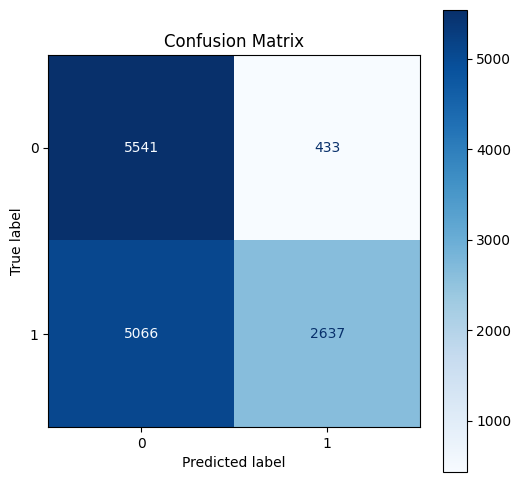

In [62]:
  # Visualize Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 6))
cm = ConfusionMatrixDisplay.from_predictions(y_val, val_pred, cmap='Blues', ax=ax, normalize=None)
ax.set_title('Confusion Matrix')
plt.grid(False)
plt.show(cm)

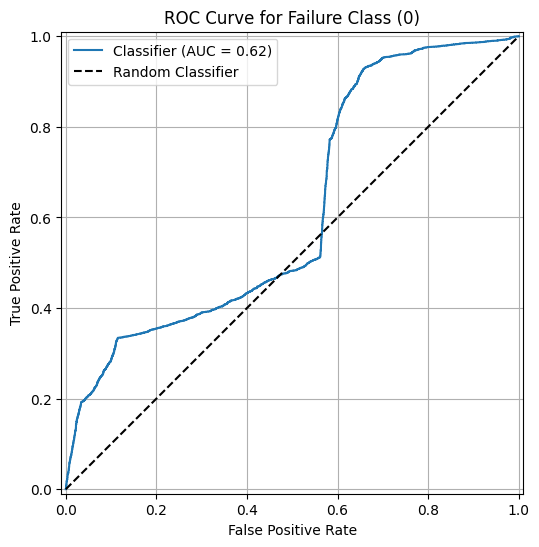

In [63]:
# Visualize ROC Curve
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_val_failure_binary, val_proba_fail, ax=ax)
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
ax.set_title('ROC Curve for Failure Class (0)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
plt.grid(True)
plt.show()

### 4.2 Pump Failure Classification — Decision Tree

#### 4.2.1 Data Loading

In [64]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [66]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

#### 4.2.2 Feature & Target Preparation

In [65]:
train = pd.read_parquet("/content/drive/MyDrive/CSV/data_clean/classification/classification_pump_train.parquet")
val   = pd.read_parquet("/content/drive/MyDrive/CSV/data_clean/classification/classification_pump_val.parquet")
test  = pd.read_parquet("/content/drive/MyDrive/CSV/data_clean/classification/classification_pump_test.parquet")

print(train.shape, val.shape, test.shape)
print("Train distribution:\n", train["future_failure"].value_counts())

(63827, 40) (13677, 40) (13679, 40)
Train distribution:
 future_failure
1    40029
0    23798
Name: count, dtype: int64


In [67]:
TARGET = "future_failure"

drop_cols = ["asset_id", "asset_type", "timestamp", "failure_event"]

X_train = train.drop(columns=[TARGET] + drop_cols, errors="ignore")
y_train = train[TARGET]

X_val = val.drop(columns=[TARGET] + drop_cols, errors="ignore")
y_val = val[TARGET]

X_test = test.drop(columns=[TARGET] + drop_cols, errors="ignore")
y_test = test[TARGET]

#### 4.2.4 Model Training

In [68]:
dt = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced",
    max_depth=5,
    min_samples_leaf=20
)
dt.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5,
                       min_samples_leaf=20, random_state=42)

#### 4.2.5 Validation Metrics

In [69]:
FAILURE_LABEL = 0

idx_fail = list(dt.classes_).index(FAILURE_LABEL)
val_proba_fail = dt.predict_proba(X_val)[:, idx_fail]

val_pred = dt.predict(X_val)

print("=== Evaluating Failure Class (0) ===")
print(f"Accuracy: {accuracy_score(y_val, val_pred):.2f}")
print(f"Precision (failure): {precision_score(y_val, val_pred, pos_label=FAILURE_LABEL):.2f}")
print(f"Recall (failure): {recall_score(y_val, val_pred, pos_label=FAILURE_LABEL):.2f}")
print(f"F1 (failure): {f1_score(y_val, val_pred, pos_label=FAILURE_LABEL):.2f}")

y_val_binary = (y_val == FAILURE_LABEL).astype(int)
roc_auc = roc_auc_score(y_val_binary, val_proba_fail)
print(f"ROC-AUC (failure): {roc_auc:.2f}")

best_dt_f1_pump = f1_score(y_val, val_pred, pos_label=FAILURE_LABEL)
best_dt_thr_pump = 0.5 # Default threshold for predict method
best_dt_pump = dt
best_dt_auc_pump = roc_auc

=== Evaluating Failure Class (0) ===
Accuracy: 0.60
Precision (failure): 0.53
Recall (failure): 0.87
F1 (failure): 0.66
ROC-AUC (failure): 0.59


#### 4.2.7 Visualisations

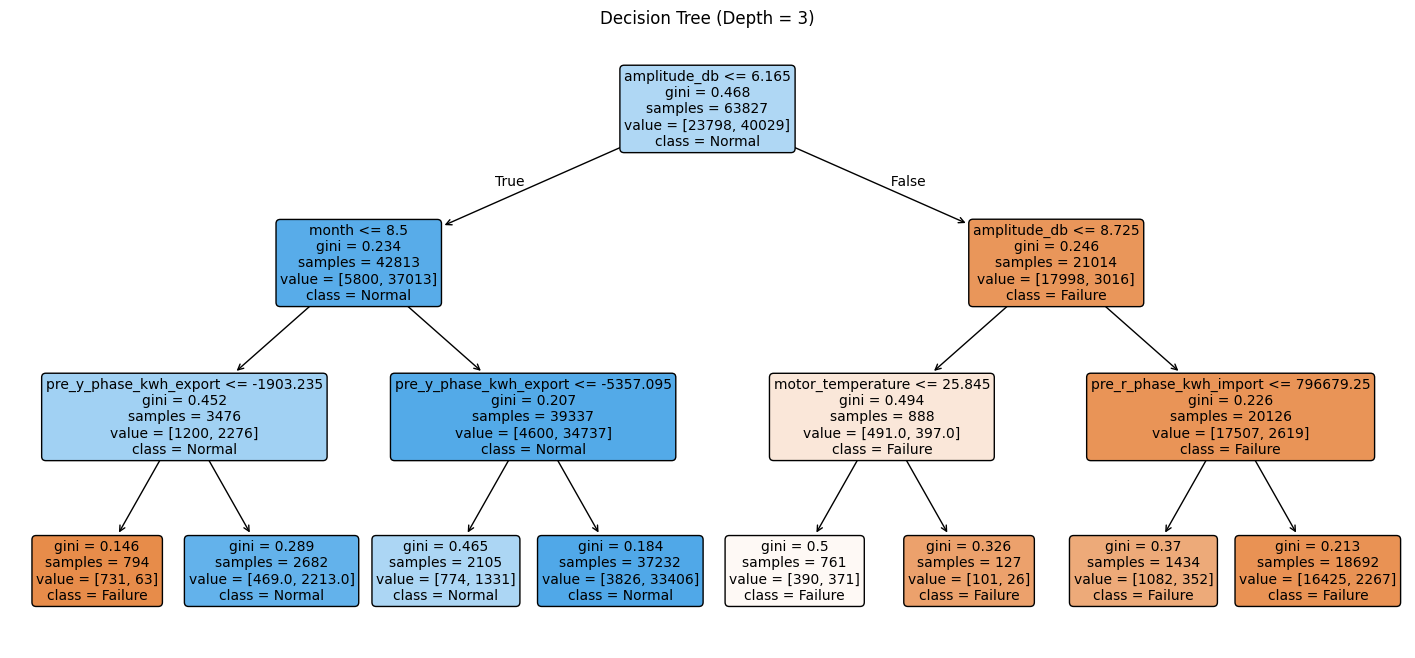

In [70]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

dt_small = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_small.fit(X_train, y_train)

plt.figure(figsize=(18, 8))
plot_tree(
    dt_small,
    feature_names=X_train.columns,
    class_names=["Failure", "Normal"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree (Depth = 3)")
plt.show()

The visualization above displays the structure of the trained Decision Tree. Each node represents a decision rule based on a feature, leading to either another decision or a final classification (leaf node). The color of the nodes indicates the majority class in that node, and the `value` array shows the number of samples for each class in that node. Due to the dataset's class imbalance and the complexity of the tree, the plot can be quite dense.

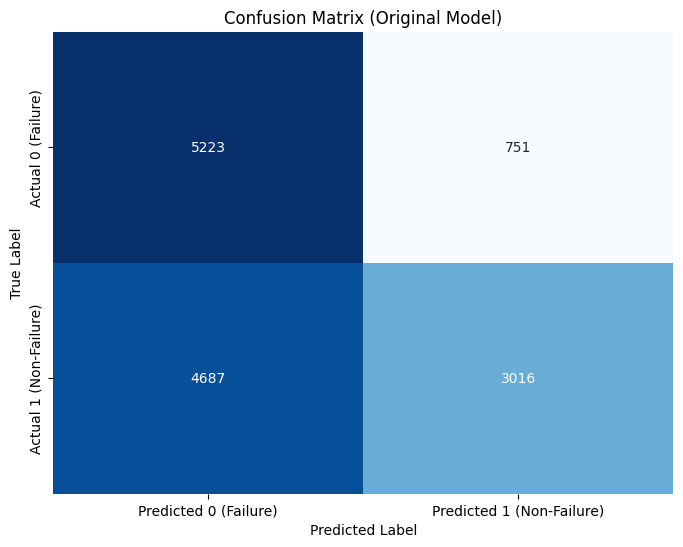

In [71]:
# Get the confusion matrix from the original model evaluation
cm_original = confusion_matrix(y_val, val_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_original, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0 (Failure)', 'Predicted 1 (Non-Failure)'],
            yticklabels=['Actual 0 (Failure)', 'Actual 1 (Non-Failure)'])
plt.title('Confusion Matrix (Original Model)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

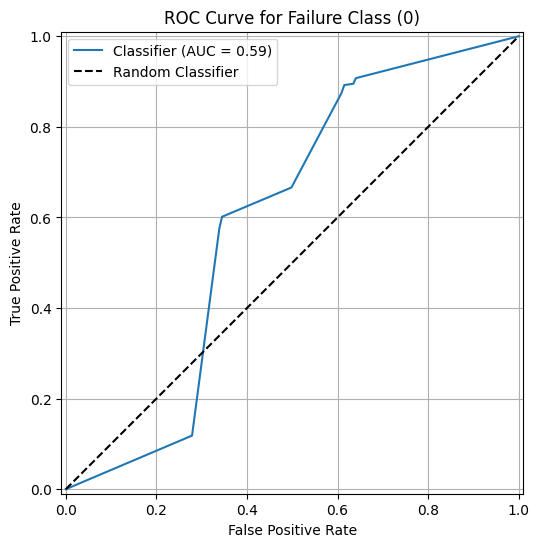

In [72]:
# Visualize ROC Curve
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_val_failure_binary, val_proba_fail, ax=ax)
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
ax.set_title('ROC Curve for Failure Class (0)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
plt.grid(True)
plt.show()

### 4.3 Pump Failure Classification — Random Forest

#### Notes:
- The minority class (failure) is encoded as **0**.
- Therefore, evaluation metrics treat class 0 as the positive class.
- ROC-AUC is computed using probability of class 0.

#### 4.3.1 Data Loading

In [73]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [74]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

#### 4.3.2 Feature & Target Preparation

In [75]:
train = pd.read_parquet("/content/drive/MyDrive/CSV/data_clean/classification/classification_pump_train.parquet")
val   = pd.read_parquet("/content/drive/MyDrive/CSV/data_clean/classification/classification_pump_val.parquet")
test  = pd.read_parquet("/content/drive/MyDrive/CSV/data_clean/classification/classification_pump_test.parquet")

print(train.shape, val.shape, test.shape)
print("Train distribution:\n", train["future_failure"].value_counts())

(63827, 40) (13677, 40) (13679, 40)
Train distribution:
 future_failure
1    40029
0    23798
Name: count, dtype: int64


In [76]:
TARGET = "future_failure"

drop_cols = ["asset_id", "asset_type", "timestamp", "failure_event"]

X_train = train.drop(columns=[TARGET] + drop_cols, errors="ignore")
y_train = train[TARGET]

X_val = val.drop(columns=[TARGET] + drop_cols, errors="ignore")
y_val = val[TARGET]

X_test = test.drop(columns=[TARGET] + drop_cols, errors="ignore")
y_test = test[TARGET]

#### 4.3.4 Model Training

In [77]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=3,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

print("Class order:", rf.classes_)

Class order: [0 1]


#### 4.3.5 Validation Metrics

In [78]:
FAILURE_LABEL = 0

# Get probability of failure
idx_fail = list(rf.classes_).index(FAILURE_LABEL)
val_proba_fail = rf.predict_proba(X_val)[:, idx_fail]

# Default predicted labels
val_pred = rf.predict(X_val)

print("=== Evaluating Failure Class (0) ===")
print("Accuracy (overall):", round(accuracy_score(y_val, val_pred), 4))
print("Precision (failure):", round(precision_score(y_val, val_pred, pos_label=FAILURE_LABEL), 4))
print("Recall (failure):", round(recall_score(y_val, val_pred, pos_label=FAILURE_LABEL), 4))
print("F1 (failure):", round(f1_score(y_val, val_pred, pos_label=FAILURE_LABEL), 4))

# For ROC-AUC, we need class 0 to be the positive class.
y_val_failure_binary = (y_val == FAILURE_LABEL).astype(int)
roc_auc = roc_auc_score(y_val_failure_binary, val_proba_fail)
print("ROC-AUC (failure):", round(roc_auc, 4))

best_rf_f1_pump = f1_score(y_val, val_pred, pos_label=FAILURE_LABEL)
best_rf_thr_pump = 0.5 # Default threshold for predict method
best_rf_pump = rf
best_rf_auc_pump = roc_auc

=== Evaluating Failure Class (0) ===
Accuracy (overall): 0.7722
Precision (failure): 0.7342
Recall (failure): 0.7503
F1 (failure): 0.7421
ROC-AUC (failure): 0.805


#### 4.3.6 Thresholding & Optimal Threshold Selection

In [79]:
print("Threshold tuning:")
for t in [0.01, 0.02, 0.05, 0.1, 0.2]:
    preds = np.where(val_proba_fail >= t, 0, 1)

    prec = precision_score(y_val, preds, pos_label=0)
    rec  = recall_score(y_val, preds, pos_label=0)
    f1   = f1_score(y_val, preds, pos_label=0)

    print(f"t={t} | Precision={prec:.4f} | Recall={rec:.3f} | F1={f1:.4f}")

Threshold tuning:
t=0.01 | Precision=0.4368 | Recall=1.000 | F1=0.6080
t=0.02 | Precision=0.4368 | Recall=1.000 | F1=0.6080
t=0.05 | Precision=0.4368 | Recall=1.000 | F1=0.6080
t=0.1 | Precision=0.4368 | Recall=1.000 | F1=0.6080
t=0.2 | Precision=0.4664 | Recall=0.949 | F1=0.6254


Random Forest achieved ROC-AUC of 0.61, indicating moderate ranking ability. However, due to extreme imbalance (0.15% failure rate), the default 0.5 threshold resulted in zero predicted failures. Threshold tuning was required to recover meaningful recall.

#### 4.3.7 Visualisations

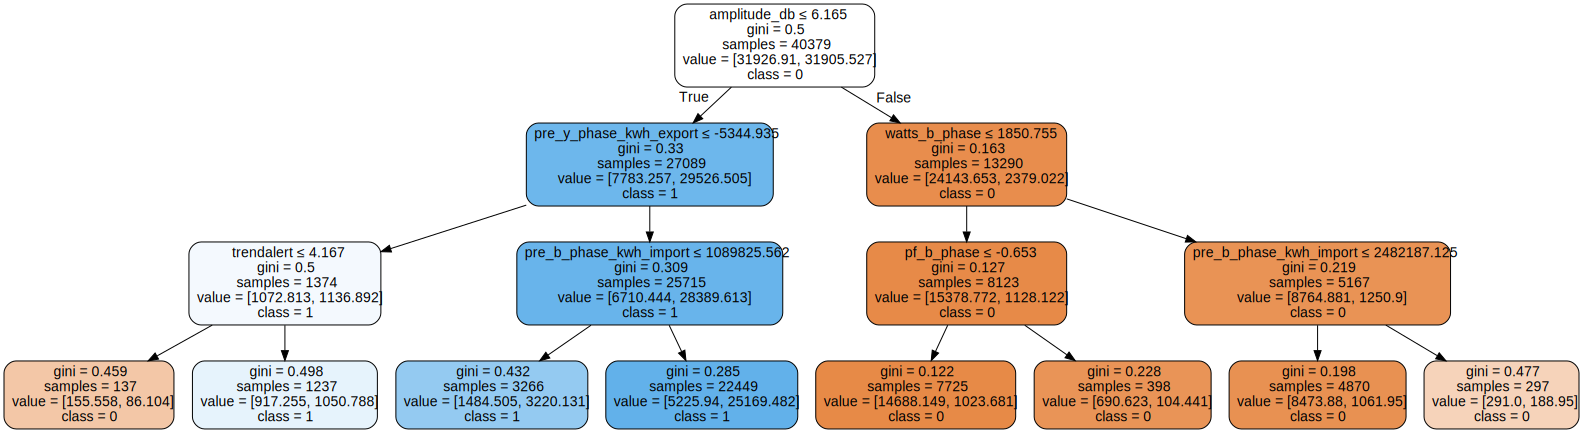

In [81]:
from sklearn.tree import export_graphviz
import graphviz

# Select a single tree from the Random Forest (e.g., the first one)
tree_to_visualize = rf.estimators_[0]

# Export the tree to a DOT format file, limiting the depth for visualization
dot_data = export_graphviz(tree_to_visualize,
                           out_file=None,
                           feature_names=X_train.columns,
                           class_names=[str(c) for c in rf.classes_],  # Convert class names to strings
                           filled=True,
                           rounded=True,
                           special_characters=True,
                           max_depth=3) # Limit the depth for better visualization

# Render the DOT data to a Graphviz object, with a smaller size
graph = graphviz.Source(dot_data)

# Display the graph
graph

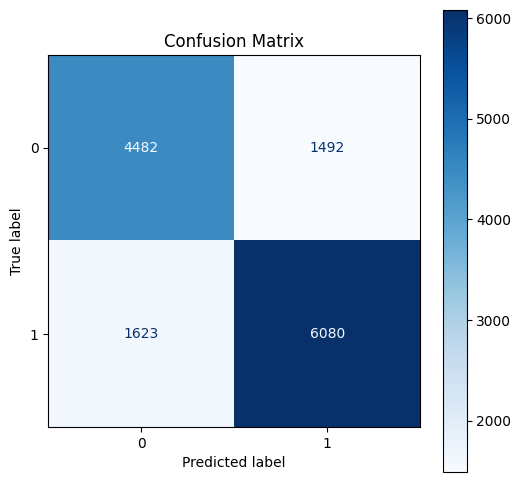

In [82]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Visualize Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 6))
cm = ConfusionMatrixDisplay.from_predictions(y_val, val_pred, cmap='Blues', ax=ax, normalize=None)
ax.set_title('Confusion Matrix')
plt.grid(False)
plt.show()

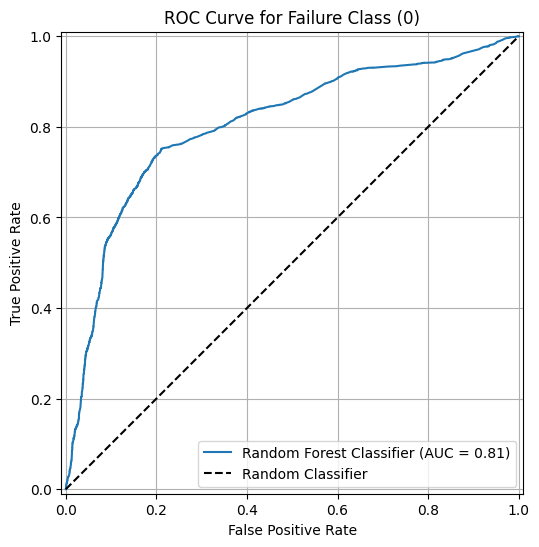

In [83]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
import matplotlib.pyplot as plt

# Convert true labels to binary (failure = 1)
y_val_failure_binary = (y_val == FAILURE_LABEL).astype(int)

# Plot ROC Curve
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_val_failure_binary, val_proba_fail, ax=ax, name='Random Forest Classifier')
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
ax.set_title('ROC Curve for Failure Class (0)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
plt.grid(True)
plt.show()

### 4.5 PUMP - Compare models (Validation) + select best

In [84]:
pump_val_table = pd.DataFrame([
    {"model":"LogReg", "val_f1": best_lr_f1_pump, "val_auc": best_lr_auc_pump, "thr": best_lr_thr_pump},
    {"model":"DecTree", "val_f1": best_dt_f1_pump, "val_auc": best_dt_auc_pump, "thr": best_dt_thr_pump},
    {"model":"RandForest", "val_f1": best_rf_f1_pump, "val_auc": best_rf_auc_pump, "thr": best_rf_thr_pump},
]).sort_values("val_auc", ascending=False)

display(pump_val_table)

best_model_name_pump = pump_val_table.iloc[0]["model"]
best_thr_final_pump = float(pump_val_table.iloc[0]["thr"])

if best_model_name_pump == "LogReg":
    best_model_pump = best_lr_pump
elif best_model_name_pump == "DecTree":
    best_model_pump = best_dt_pump
else:
    best_model_pump = best_rf_pump

print("Selected PUMP model:", best_model_name_pump, "thr:", round(best_thr_final_pump,2))

,model,val_f1,val_auc,thr
2,RandForest,0.742114,0.805040,0.500000
0,LogReg,0.668714,0.618248,0.455455
1,DecTree,0.657643,0.594461,0.500000


Selected PUMP model: RandForest thr: 0.5


### 4.6 PUMP - Final train (Train+Val) + Test evaluation

PUMP TEST — RandForest
Precision: 0.1572 Recall: 0.3687 F1: 0.2204 AUC: 0.7548


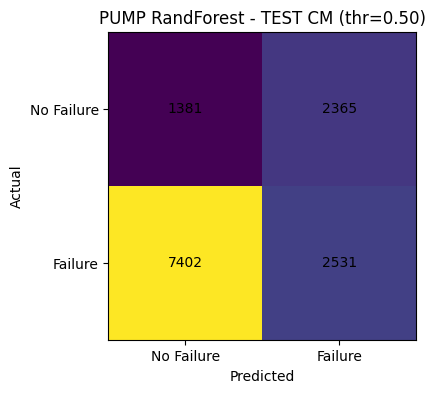

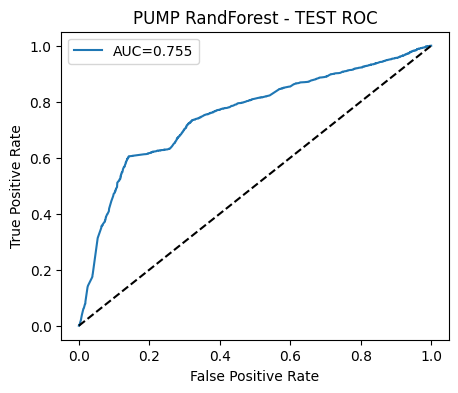

In [85]:
X_trainval = pd.concat([X_train, X_val], axis=0)
y_trainval = np.concatenate([y_train, y_val])

# Initialize a new scaler for the combined train+val data if LogReg is selected
scaler_pump_final = StandardScaler()

if best_model_name_pump == "LogReg":
    # Scale combined train+val data
    Xtrv_s = scaler_pump_final.fit_transform(X_trainval)
    Xte_s  = scaler_pump_final.transform(X_test)

    # Fit the best Logistic Regression model on scaled combined data
    best_model_pump.fit(Xtrv_s, y_trainval)
    # Get probability of the FAILURE_LABEL (class 0)
    test_prob_pump = best_model_pump.predict_proba(Xte_s)[:, FAILURE_LABEL]
else:
    # No scaling needed for Decision Tree/Random Forest as they are not scale-sensitive
    best_model_pump.fit(X_trainval, y_trainval)
    # Get probability of the FAILURE_LABEL (class 0)
    test_prob_pump = best_model_pump.predict_proba(X_test)[:, FAILURE_LABEL]

# Evaluate metrics using FAILURE_LABEL as the positive class
y_pred_test = (test_prob_pump >= best_thr_final_pump).astype(int)

precision = precision_score(y_test, y_pred_test, pos_label=FAILURE_LABEL, zero_division=0)
recall = recall_score(y_test, y_pred_test, pos_label=FAILURE_LABEL, zero_division=0)
f1 = f1_score(y_test, y_pred_test, pos_label=FAILURE_LABEL, zero_division=0)

y_test_binary_for_auc = (y_test == FAILURE_LABEL).astype(int)
auc = roc_auc_score(y_test_binary_for_auc, test_prob_pump) if len(np.unique(y_test_binary_for_auc)) > 1 else np.nan

cm = confusion_matrix(y_test, y_pred_test, labels=[0,1]) # ensure order for CM plot

print("PUMP TEST —", best_model_name_pump)
print(f"Precision: {precision:.4f} Recall: {recall:.4f} F1: {f1:.4f} AUC: {auc:.4f}")
plot_cm(cm, f"PUMP {best_model_name_pump} - TEST CM (thr={best_thr_final_pump:.2f})")
plot_roc(y_test_binary_for_auc, test_prob_pump, f"PUMP {best_model_name_pump} - TEST ROC")

### 4.7 PUMP - Feature importance / coefficients

,0
amplitude_db,0.151876
apparent_power_kva,0.108524
b_phase_current,0.100407
y_phase_current,0.095488
r_phase_current,0.077380
pf_r_phase,0.070167
avg_current,0.063126
pf_avg,0.058976
reactive_power_kvar,0.053270
realtime_active_power_kw,0.045990


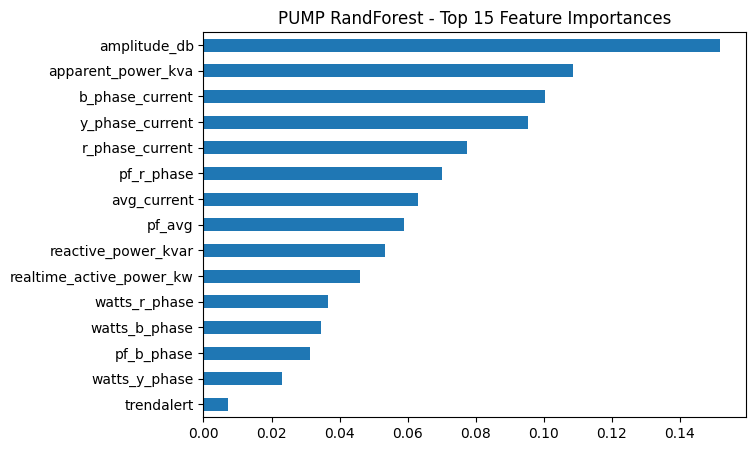

In [86]:
if best_model_name_pump in ["DecTree", "RandForest"]:
    importances = pd.Series(best_model_pump.feature_importances_, index=X_train.columns).sort_values(ascending=False)
    display(importances.head(15))
    plt.figure(figsize=(7,5))
    importances.head(15).iloc[::-1].plot(kind="barh")
    plt.title(f"PUMP {best_model_name_pump} - Top 15 Feature Importances")
    plt.show()
elif best_model_name_pump == "LogReg":
    coefs = pd.Series(best_model_pump.coef_[0], index=X_train.columns).sort_values(key=abs, ascending=False)
    display(coefs.head(15))
    plt.figure(figsize=(7,5))
    coefs.head(15).iloc[::-1].plot(kind="barh")
    plt.title("PUMP Logistic Regression - Top 15 Coefficients")
    plt.show()

### 4.8 PUMP - Error analysis (False Negatives / False Positives)

In [87]:
pump_pred_test = (test_prob_pump >= best_thr_final_pump).astype(int)
err_pump = X_test.copy()
err_pump["actual"] = y_test
err_pump["pred"] = pump_pred_test
err_pump["prob"] = test_prob_pump

fn_pump = err_pump[(err_pump["actual"]==FAILURE_LABEL) & (err_pump["pred"]!=FAILURE_LABEL)]
fp_pump = err_pump[(err_pump["actual"]!=FAILURE_LABEL) & (err_pump["pred"]==FAILURE_LABEL)]

print("PUMP False Negatives:", len(fn_pump))
print("PUMP False Positives:", len(fp_pump))

display(fn_pump.sort_values("prob", ascending=False).head(10))

PUMP False Negatives: 2365
PUMP False Positives: 7402


,run_status,realtime_active_power_kw,watts_r_phase,watts_y_phase,watts_b_phase,pf_avg,pf_r_phase,pf_y_phase,pf_b_phase,avg_current,...,trendalert,amplitude_db,motor_temperature,hour,dayofweek,month,is_weekend,actual,pred,prob
13678,4.0,5160.26,1607.35,1726.77,1826.13,-0.99,-0.99,-1.0,-0.99,9.08,...,6.0,97.29,24.5,17,6,2,1,0,1,0.866673
13664,4.0,5164.15,1616.64,1717.96,1829.56,-0.99,-0.99,-1.0,-1.00,9.10,...,6.0,97.29,24.5,16,6,2,1,0,1,0.866424
13663,4.0,5156.08,1610.27,1726.45,1819.37,-0.99,-0.99,-1.0,-0.99,9.11,...,6.0,97.29,24.5,16,6,2,1,0,1,0.865043
13662,4.0,5156.08,1610.27,1726.45,1819.37,-0.99,-0.99,-1.0,-0.99,9.11,...,6.0,97.29,24.5,16,6,2,1,0,1,0.865043
13667,4.0,5157.30,1622.99,1716.52,1817.78,-0.99,-0.99,-1.0,-0.99,9.08,...,6.0,97.29,24.5,16,6,2,1,0,1,0.863996
13668,4.0,5160.97,1622.57,1709.31,1829.09,-0.99,-0.99,-1.0,-1.00,9.07,...,6.0,97.29,24.5,17,6,2,1,0,1,0.863554
13669,4.0,5146.44,1617.09,1706.11,1823.23,-0.99,-0.98,-1.0,-1.00,9.03,...,6.0,97.29,24.5,17,6,2,1,0,1,0.863329
13665,4.0,5157.62,1615.69,1710.26,1831.68,-0.99,-0.99,-1.0,-1.00,9.08,...,6.0,97.29,24.5,16,6,2,1,0,1,0.863302
13666,4.0,5147.70,1610.81,1706.64,1830.25,-0.99,-0.98,-1.0,-1.00,9.04,...,6.0,97.29,24.5,16,6,2,1,0,1,0.861231
13539,4.0,5165.13,1589.83,1750.33,1824.97,-0.99,-0.99,-1.0,-0.99,9.13,...,6.0,97.29,24.5,5,6,2,1,0,1,0.861185
